## Task 1 :Dataset Understanding

In [45]:
import pandas as pd
import matplotlib.pyplot as plt

## Load dataset

In [46]:
df = pd.read_csv("customer_churn_nn.csv")
df.head()

,customer_id,region,plan_type,contract_type,payment_method,tenure_months,monthly_charges_inr,avg_login_days_per_month,support_tickets_last_90_days,payment_delay_days,data_usage_gb,satisfaction_score,last_complaint_days_ago,discount_percent,autopay_enabled,referral_count,churn
0,CUST0001,South,Standard,Month-to-month,Debit Card,30,687.40,13,0,0,87.97,8.0,67,0,0,0,0
1,CUST0002,West,Premium,Month-to-month,Wallet,15,1029.74,22,3,1,82.17,5.7,69,0,0,0,0
2,CUST0003,Central,Standard,Month-to-month,Credit Card,72,732.07,13,0,11,89.39,6.4,63,10,0,0,0
3,CUST0004,West,Premium,Month-to-month,Credit Card,22,959.51,19,2,3,139.73,7.2,130,5,0,0,0
4,CUST0005,North,Premium,Month-to-month,Net Banking,11,890.20,18,2,6,156.43,5.8,0,5,1,2,0


## Rows and columns

In [47]:
df.shape

(2000, 17)

The dataset has 2000 rows and 17 columns

## Column types

In [48]:
df.dtypes

customer_id                         str
region                              str
plan_type                           str
contract_type                       str
payment_method                      str
tenure_months                     int64
monthly_charges_inr             float64
avg_login_days_per_month          int64
support_tickets_last_90_days      int64
payment_delay_days                int64
data_usage_gb                   float64
satisfaction_score              float64
last_complaint_days_ago           int64
discount_percent                  int64
autopay_enabled                   int64
referral_count                    int64
churn                             int64
dtype: object

The dataset has numerical columns and categorical columns.
The target column is churn.

## Missing values

In [49]:
df.isnull().sum()

customer_id                     0
region                          0
plan_type                       0
contract_type                   0
payment_method                  0
tenure_months                   0
monthly_charges_inr             0
avg_login_days_per_month        0
support_tickets_last_90_days    0
payment_delay_days              0
data_usage_gb                   0
satisfaction_score              0
last_complaint_days_ago         0
discount_percent                0
autopay_enabled                 0
referral_count                  0
churn                           0
dtype: int64

There are no missing values in the dataset.

## Statistical summary

In [50]:
df.describe()

,tenure_months,monthly_charges_inr,avg_login_days_per_month,support_tickets_last_90_days,payment_delay_days,data_usage_gb,satisfaction_score,last_complaint_days_ago,discount_percent,autopay_enabled,referral_count,churn
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.00000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,25.362000,766.487295,18.099000,1.953000,3.555000,90.007625,6.87395,46.616500,8.255000,0.597500,0.918000,0.015500
std,14.128651,393.420070,5.400628,1.463852,3.885682,53.215719,1.52428,55.065775,7.553708,0.490524,1.041546,0.123561
min,1.000000,255.450000,0.000000,0.000000,0.000000,0.500000,1.00000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,15.000000,427.782500,15.000000,1.000000,1.000000,51.777500,5.87500,6.000000,0.000000,0.000000,0.000000,0.000000
50%,23.000000,688.355000,18.000000,2.000000,2.000000,80.245000,6.80000,28.500000,5.000000,1.000000,1.000000,0.000000
75%,33.000000,1007.372500,22.000000,3.000000,5.000000,119.097500,8.00000,68.000000,15.000000,1.000000,1.000000,0.000000
max,72.000000,2156.520000,30.000000,8.000000,31.000000,265.510000,10.00000,424.000000,20.000000,1.000000,7.000000,1.000000


The numerical columns have different ranges, so scaling will be needed before neural network training.

## Target distribution

In [51]:
df["churn"].value_counts()

churn
0    1969
1      31
Name: count, dtype: int64

## Target chart

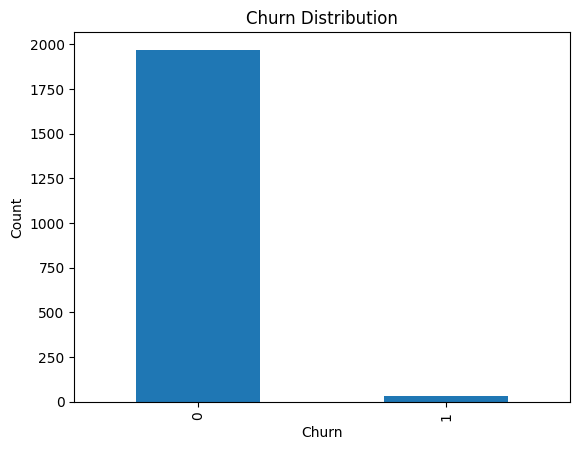

In [52]:
df["churn"].value_counts().plot(kind="bar")
plt.title("Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Count")
plt.show()

The target variable is churn.
0 means customer retained.
1 means customer churned.

The dataset is imbalanced because retained customers are much higher than churned customers.

## Task 2: Data Preprocessing

In [53]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler


df = df.drop("customer_id", axis=1)

df.isnull().sum()

region                          0
plan_type                       0
contract_type                   0
payment_method                  0
tenure_months                   0
monthly_charges_inr             0
avg_login_days_per_month        0
support_tickets_last_90_days    0
payment_delay_days              0
data_usage_gb                   0
satisfaction_score              0
last_complaint_days_ago         0
discount_percent                0
autopay_enabled                 0
referral_count                  0
churn                           0
dtype: int64

There are no missing values in the dataset.

In [54]:
label = LabelEncoder()

df["region"] = label.fit_transform(df["region"])
df["plan_type"] = label.fit_transform(df["plan_type"])
df["contract_type"] = label.fit_transform(df["contract_type"])
df["payment_method"] = label.fit_transform(df["payment_method"])

Categorical columns were converted into numbers.

In [55]:
X = df.drop("churn", axis=1)
y = df["churn"]

X stores input columns.
y stores the target column.

In [56]:
scaler = StandardScaler()
X = scaler.fit_transform(X)

The input data was scaled so all values are in a similar range.

In [57]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

The data was split into training and testing data.
80% data is used for training.
20% data is used for testing.

In [58]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(1600, 15)
(400, 15)
(1600,)
(400,)


Data preprocessing is completed.
The dataset is now ready for neural network training.

## Task 3: Neural Network Model Building

In [59]:
from sklearn.neural_network import MLPClassifier

model = MLPClassifier(hidden_layer_sizes=10, max_iter=500)
model.fit(X_train, y_train)
print("Model training completed")



Model training completed


The neural network model was trained successfully.

The model uses:
- one hidden layer
- 10 neurons
- training iterations to improve learning

The model learned patterns from the training dataset.